# (리뷰) 산점도

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [시각화]

In [1]:
import matplotlib.pyplot as plt 

`-` $(x,y)$를 점으로 찍은것.. 

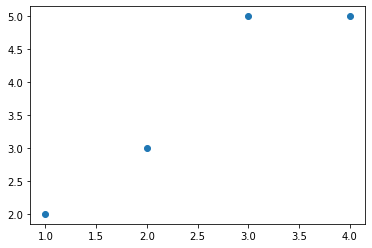

In [2]:
x=[1,2,3,4]
y=[2,3,5,5]
plt.plot(x,y,'o') ## 'o' 

`-` 산점도는 보통 $X$와 $Y$의 관계를 알고 싶을 경우 그린다. 

- 박스클랏과 히스토그램을 위해서는 하나의 변수만 필요, 산점도를 위해서는 두개의 변수가 필요함. 
- 두변수 $\to$ 두변수의 관계!

#### 몸무게와 키

`-` 아래와 같은 자료를 수집하였다고 하자. 

- 몸무게 = [44,48,49,58,62,68,69,70,76,79]
- 키 = [159,160,162,165,167,162,165,175,165,172]

In [67]:
x=[44,48,49,58,62,68,69,70,76,79] # 몸무게  
y=[159,160,162,165,167,162,165,175,165,172] # 키 

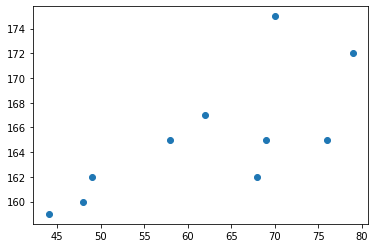

In [68]:
plt.plot(x,y,'o')

- 키가 큰 사람일수록 몸무게도 많이 나감 (**반대도 성립**) 
- 키와 몸무게는 관계가 있어보인다. (정비례) // 네이버검색 "정비례반비례" 지식백과탭 3번째. 

`-` 얼만큼 정비례인지? 

- 이 질문에 대답하려면 상관계수를 알아야한다. 
- 상관계수에 대한 개념도는 산점도를 이해함에 있어서 핵심개념이다. 

#### 상관계수 (몸무게-키 예제의 심층분석을 위한 핵심 통계개념) 

`-` (표본)상관계수 

$$r=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2 \sum_{i=1}^{n}(y_i-\bar{y})^2 }}$$

- 복잡해보이지만 하여튼 (1) 분자계산하고 (2) 분모계산해서 분자를 분모로 나누면 되는 것 
- 분모는 계산했다고 치자. 그걸 어떠한 상수 $c$로 생각하고 분자안에 넣을수도 있다. 

$$r=\sum_{i=1}^{n}\frac{1}{c}(x_i-\bar{x})(y_i-\bar{y})$$

- 위의 식은 아래와 같이 쓸 수 있다. 

$$r=\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}}\frac{y_i-\bar{y}}{\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}\right)$$

- 편의상 아래와 같이 정의하자. $z_x=\frac{x_i-\bar{x}}{\sqrt{\sum_{i=1}^n(x_i-\bar{x})^2}}, z_y=\frac{y_i-\bar{y}}{\sqrt{\sum_{i=1}^n(y_i-\bar{y})^2}}$ 라고 정의하자. 

- 결국 아래와 같은 모양이다. 

$$r=\sum_{i=1}^{n}z_x z_y$$

`-` 의미? 

In [69]:
x= np.array(x)
y= np.array(y)

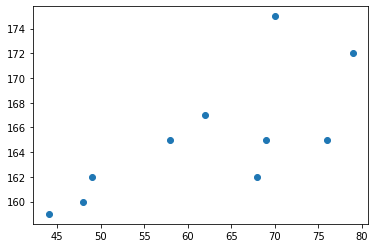

In [70]:
plt.plot(x,y,'o')

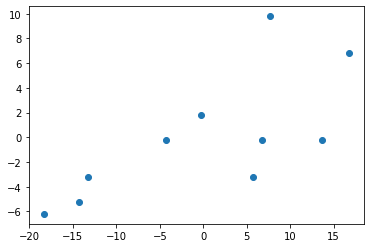

In [71]:
plt.plot(x-np.mean(x),y-np.mean(y),'o')

`-` $a=\sqrt{\sum_{i=1}^n (x_i-\bar{x})^2}, b=\sqrt{\sum_{i=1}^n (y_i-\bar{y})^2}$

In [72]:
a=np.sqrt(sum((x-np.mean(x))**2))
b=np.sqrt(sum((y-np.mean(y))**2))

In [73]:
a,b

(36.58004920718396, 15.218409903797438)

- 아무튼 $a>b$ 이므로 $\{x_i\}$들이 $\{y_i\}$보다 좀 더 퍼져있다. (=평균근처에 몰려있지 않다)

`-` 사실 $a=\sqrt{n}\times {\tt np.std(x)}$, $b=\sqrt{n}\times {\tt np.std(y)}$ 해도된다. 

In [84]:
n=len(x)
np.sqrt(n)*np.std(x),np.sqrt(n)*np.std(y)

(36.58004920718397, 15.21840990379744)

- 즉 np.std(x)는 $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2}$를 계산해준다. 

- 참고로 np.std(x,ddof=1)을 하면 $\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2}$ 이 계산된다. 

`-` $(z_x,z_y)$를 그려보자!

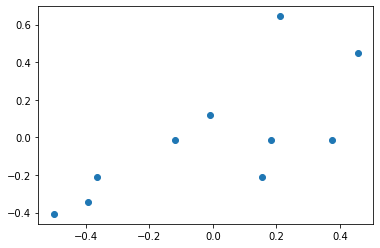

In [48]:
zx=(x-np.mean(x))/a
zy=(y-np.mean(y))/b
plt.plot(zx,zy,'o')

- 평균도 비슷하고 퍼진정도도 비슷하다. 

`-` 질문1: $r$ 의 값이 양수인가? 음수인가? 

plotly 사용하여 그려보자. 

In [158]:
import plotly.express as px
from IPython.display import HTML
fig=px.scatter(x=zx,y=zy)
HTML(fig.to_html(include_plotlyjs='cdn', include_mathjax=False))

- $z_x$와 $z_y$의 곱한값이 양수인것과 음수인것을 체크해보자. 
- 양수인쪽이 많은가, 음수인쪽이 많은가? 
- $z_x$와 $z_y$의 곱한값을 모두 더하면 양수가 될까 음수가 될까? 

`-` 질문2: 아래와 같은 두개의 데이터set이 있다고 하자. 

In [152]:
x1=np.arange(0,10,0.1)
y1=x1+np.random.normal(loc=0,scale=7,size=len(x1))

In [153]:
x2=np.arange(0,10,0.1)
y2=x2+np.random.normal(loc=0,scale=1,size=len(x2))

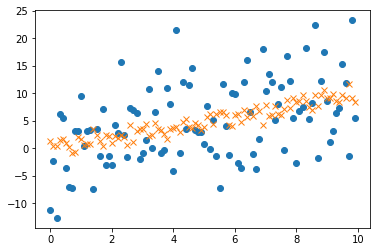

In [154]:
plt.plot(x1,y1,'o')
plt.plot(x2,y2,'x')

각 데이터셋의 표준상관계수를 각각 $r_1$, $r_2$라고 하자. 

(1) $r_1$, $r_2$는 양수인가 음수인가? 

(2) $r_1$, $r_2$의 값 중 어떠한 값이 더 절대값이 큰가? 

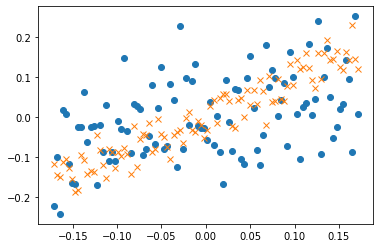

In [155]:
n=len(x1)
xx1= (x1-np.mean(x1)) / (np.std(x1)*np.sqrt(n))
yy1= (y1-np.mean(y1)) / (np.std(y1)*np.sqrt(n))
xx2= (x2-np.mean(x2)) / (np.std(x2)*np.sqrt(n))
yy2= (y2-np.mean(y2)) / (np.std(y2)*np.sqrt(n))
plt.plot(xx1,yy1,'o')
plt.plot(xx2,yy2,'x')

#### Appendex: 표본XX vs 모XX

`-` 표본상관계수라는 것과 모상관계수가 있음 
- 표본상관계수는 줄여서 상관계수라 부르기도 함
- 모상관계수를 줄여서 상관계수라 부르기도 함 
- ?? 


`-` 모평균과 표본평균이 있음. 
- 모평균을 줄여서 평균이라고 부름. 
- 표본평균도 줄여서 평균이라 부르기도함. 
- ?? 

In [1]:
pwd

'/home/cgb/Dropbox/01_yechan/_notebooks'

In [ ]:
Dropbox/01_yechan/_notebooks/2021-09-05-Unequalized_Hawkes_Bay_NZ.jpeg

In [4]:
import cv2 as cv

In [6]:
cv.__version__

'4.5.3'